# Banco de dados MNIST

![Exemplo MNIST](imgs/mnist-3.0.1.png)

O **banco de dados MNIST** (Modified National Institute of Standards and Technology database) é um conjunto de dados clássico em aprendizado de máquina e visão computacional.

Ele consiste em:

- **70.000 imagens em tons de cinza** de dígitos manuscritos (0–9)
  - **60.000 imagens para treinamento**
  - **10.000 imagens para teste**
- Cada imagem possui **28x28 pixels** (achatada para 784 características em muitos modelos)
- Cada imagem é rotulada com o dígito correto (0–9)

**Propósito:**

O MNIST é amplamente utilizado para treinar e testar algoritmos de classificação de imagens, especialmente para avaliação de redes neurais e modelos de deep learning.

**Uso típico:**

- **Entrada:** Imagem de 28x28 pixels (geralmente achatada para um vetor de tamanho 784)
- **Saída:** Rótulo do dígito (0–9)

**Por que é popular?**

- Simples e bem compreendido
- Pequeno o suficiente para experimentos rápidos
- Bom para aprender e prototipar modelos de classificação de imagens

### 1. Download

In [ ]:
from utils import mnist

In [ ]:
# mnist.download_mnist()

### 2. Carrega dados memoria

In [1]:
from utils import mnist

In [2]:
X_train, y_train, X_test, y_test = mnist.load()

#### 2.1 Estrutura features

In [3]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784), dtype=uint8)

#### 2.2 Exemplo de 1 elemento

In [4]:
import numpy as np

np.set_printoptions(linewidth=32*4)  

print(X_train[2].reshape(28, 28))  

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0   0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0   0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   0   0   0   0  2

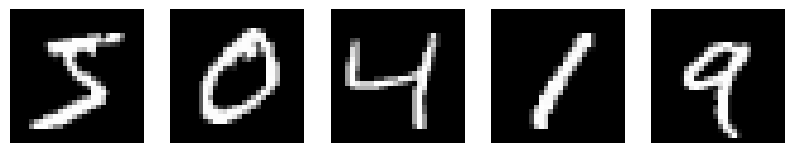

In [5]:
import matplotlib.pyplot as plt

# Number of samples to display
num_samples = 5

# Plot the first few samples
fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
for i in range(num_samples):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
plt.show()

#### 2.3 Estrutura target

In [6]:
y_train[0:5]

array([5, 0, 4, 1, 9])

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

#### 2.4 Transformacao do target

In [8]:
# one-hot encode
num_labels = len(y_train)
train_labels = np.zeros((num_labels, 10))
for i in range(num_labels):
    train_labels[i][y_train[i]] = 1

num_labels = len(y_test)
test_labels = np.zeros((num_labels, 10))
for i in range(num_labels):
    test_labels[i][y_test[i]] = 1

In [9]:
train_labels[0:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

#### 2.5 Transformacao das features

In [10]:
X_train, X_test = X_train - np.mean(X_train), X_test - np.mean(X_train)
X_train, X_test = X_train / np.std(X_train), X_test / np.std(X_train)

In [11]:
# X_train, X_test = X_train / 255, X_test /255

In [12]:
np.set_printoptions(linewidth=60*4) 
np.round(X_train[2].reshape(28, 28), 3)

array([[-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424],
       [-0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.424, -0.4

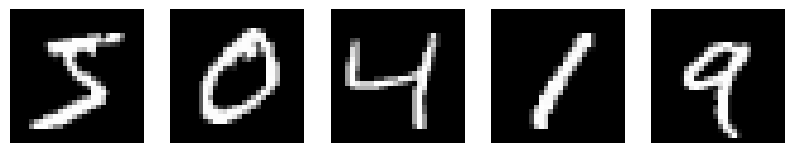

In [13]:
import matplotlib.pyplot as plt

# Number of samples to display
num_samples = 5

# Plot the first few samples
fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
for i in range(num_samples):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
plt.show()

#### 2.6 Arquitetura modelo e acuracia

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 10)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(10, 10)
        self.softmax = nn.Softmax(dim=1)

        # nn.init.zeros_(self.fc1.weight)
        # nn.init.zeros_(self.fc1.bias)
        # nn.init.zeros_(self.fc2.weight)
        # nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

epochs = 50
batch_size = 60

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    outputs = model(X_test_tensor)
    predicted = torch.argmax(outputs, 1)
    accuracy = (predicted == y_test_tensor).float().mean().item()
    print(f"Test accuracy: {accuracy*100:.2f}%")


Epoch 2/50, Loss: 2.0336
Epoch 4/50, Loss: 1.9494
Epoch 6/50, Loss: 1.8627
Epoch 8/50, Loss: 1.8158
Epoch 10/50, Loss: 1.8011
Epoch 12/50, Loss: 1.7945
Epoch 14/50, Loss: 1.7906
Epoch 16/50, Loss: 1.7876
Epoch 18/50, Loss: 1.7847
Epoch 20/50, Loss: 1.7809
Epoch 22/50, Loss: 1.7610
Epoch 24/50, Loss: 1.6959
Epoch 26/50, Loss: 1.6684
Epoch 28/50, Loss: 1.6563
Epoch 30/50, Loss: 1.6493
Epoch 32/50, Loss: 1.6442
Epoch 34/50, Loss: 1.6392
Epoch 36/50, Loss: 1.6339
Epoch 38/50, Loss: 1.6286
Epoch 40/50, Loss: 1.6237
Epoch 42/50, Loss: 1.6196
Epoch 44/50, Loss: 1.6159
Epoch 46/50, Loss: 1.6127
Epoch 48/50, Loss: 1.6098
Epoch 50/50, Loss: 1.6068
Test accuracy: 85.62%


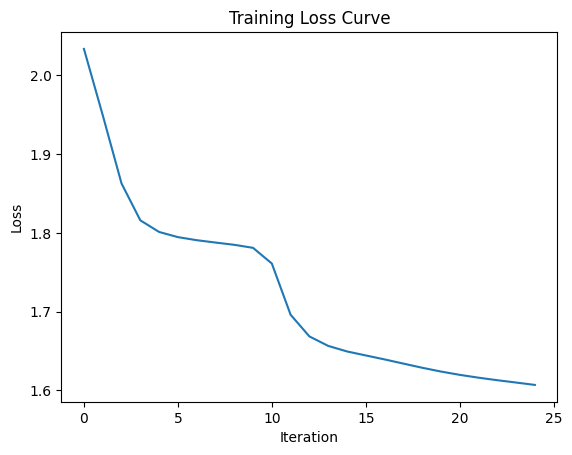

In [33]:
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

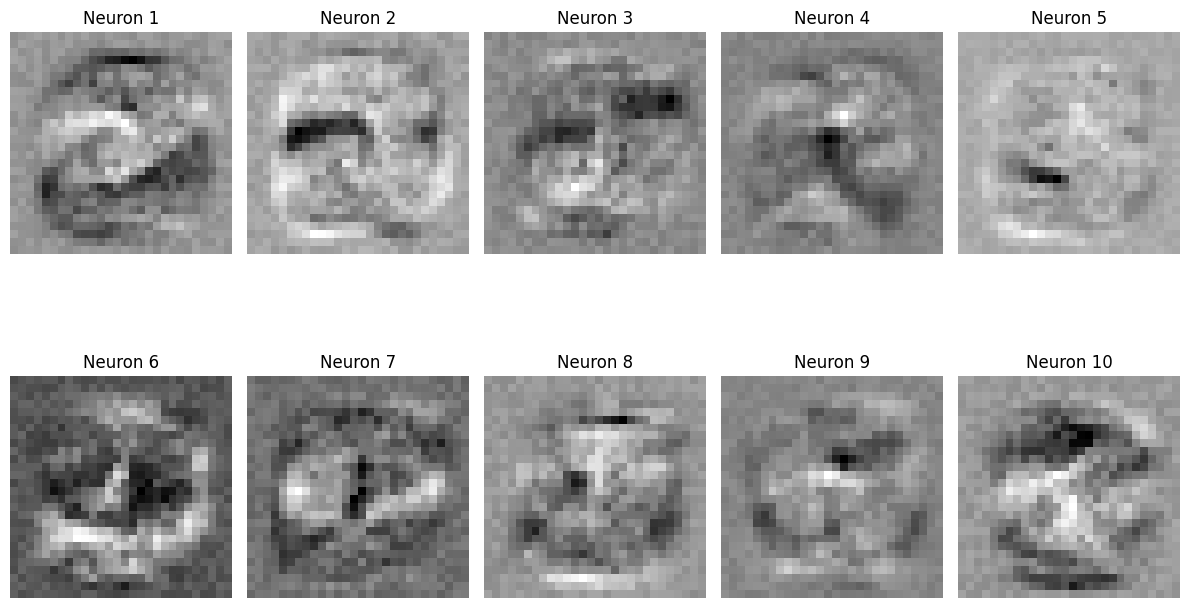

In [34]:
# Visualizacao dos pesos da primeira camada
weights = model.fc1.weight.data.numpy()
fig, axes = plt.subplots(2, 5, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i < 10:
        ax.imshow(weights[i].reshape(28, 28), cmap='gray')
        ax.set_title(f'Neuron {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

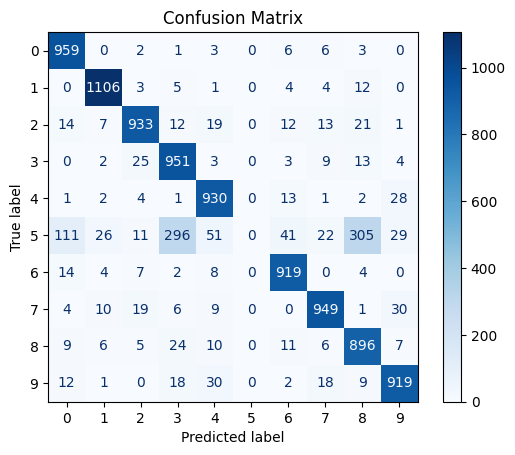

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the model
y_pred = predicted.numpy()
y_true = y_test

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


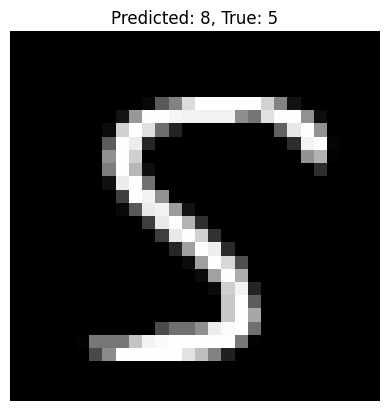

In [36]:
# Select an index from the test set
idx = 333 # Change this to visualize other samples

# Get the image and reshape for display
img = X_test[idx].reshape(28, 28)

# Get the model's prediction
with torch.no_grad():
    output = model(torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0))
    pred = torch.argmax(output, 1).item()

# Plot the image and show the prediction
plt.imshow(img, cmap='gray')
plt.title(f'Predicted: {pred}, True: {y_test[idx]}')
plt.axis('off')
plt.show()

In [37]:
model.fc1.weight.data.shape

torch.Size([10, 784])

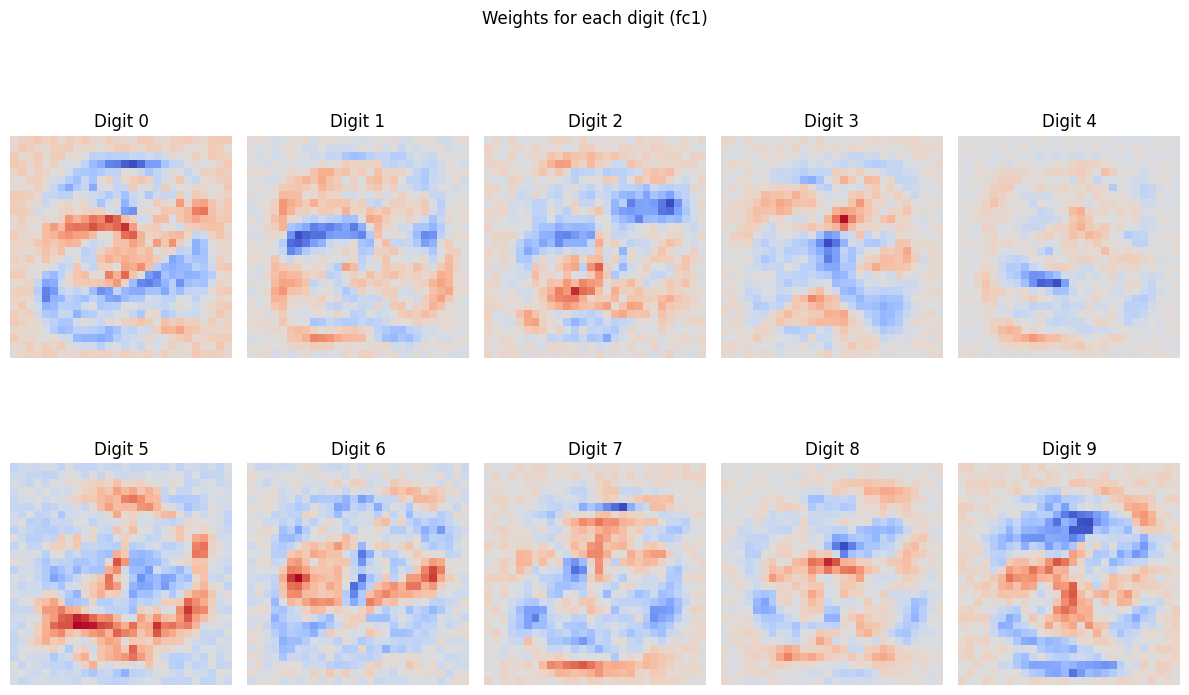

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(12, 8))
for digit in range(10):
    W = model.fc1.weight.data.numpy()[digit].reshape(28, 28)
    ax = axes.flat[digit]
    im = ax.imshow(W, cmap="coolwarm", vmin=-np.max(np.abs(W)), vmax=np.max(np.abs(W)))
    ax.set_title(f"Digit {digit}")
    ax.axis('off')
plt.suptitle("Weights for each digit (fc1)")
plt.tight_layout()
plt.show()

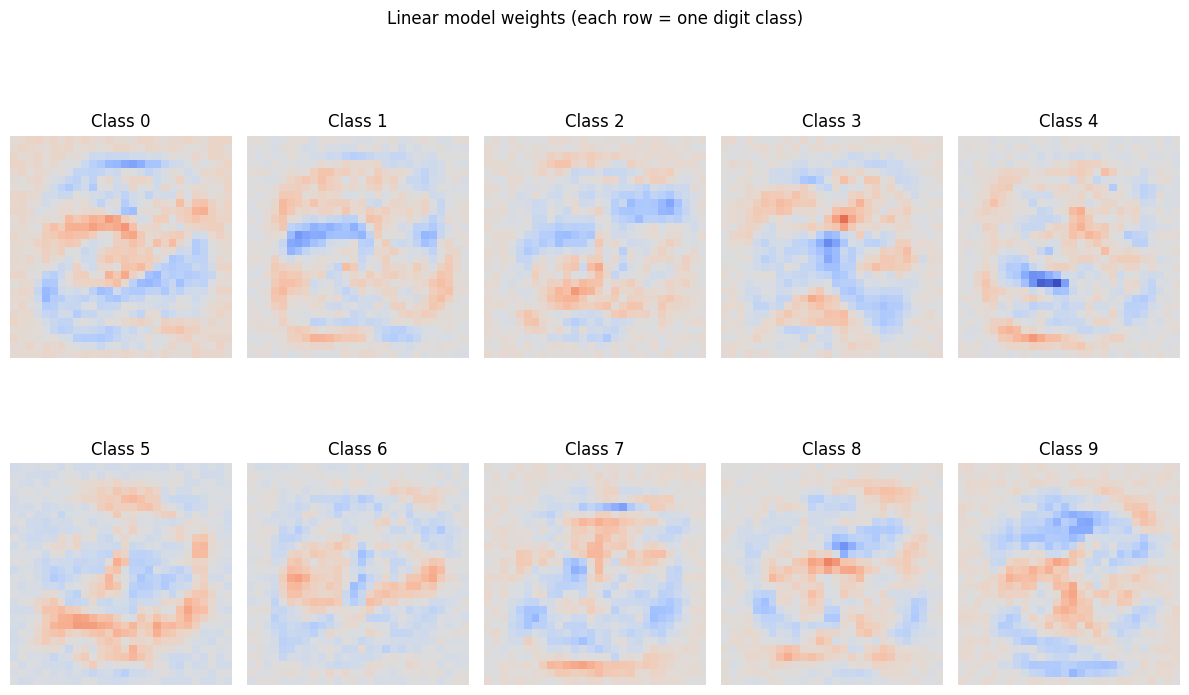

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(12, 8))

weights = model.fc1.weight.data.cpu().numpy()

for digit in range(10):
    W = weights[digit].reshape(28, 28)  # row = class digit
    ax = axes.flat[digit]
    im = ax.imshow(W, cmap="coolwarm", 
                   vmin=-np.max(np.abs(weights)), 
                   vmax=np.max(np.abs(weights)))
    ax.set_title(f"Class {digit}")
    ax.axis("off")

plt.suptitle("Linear model weights (each row = one digit class)")
plt.tight_layout()
plt.show()

### Training a CVAE to generate images of a specific digit



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST Dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)

In [ ]:
trainloader.dataset.data.shape

torch.Size([60000, 28, 28])

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(28*28 + 10, 400)  # +10 for one-hot label
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim + 10, 400)
        self.fc3 = nn.Linear(400, 28*28)

    def encode(self, x, y):
        # x: [batch, 784], y: [batch, 10]
        h = torch.relu(self.fc1(torch.cat([x, y], dim=1)))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, y):
        h = torch.relu(self.fc2(torch.cat([z, y], dim=1)))
        return torch.sigmoid(self.fc3(h))  # output image in [0,1]

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [ ]:
model = CVAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):  # small for demo, try 20+ for good results
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(trainloader):
        data = data.view(-1, 28*28).to(device)
        labels_onehot = F.one_hot(labels, num_classes=10).float().to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels_onehot)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {train_loss / len(trainloader.dataset):.4f}")

Epoch 1, Loss: 163.0764
Epoch 2, Loss: 119.4906
Epoch 3, Loss: 112.3001
Epoch 4, Loss: 109.0643


KeyboardInterrupt: 

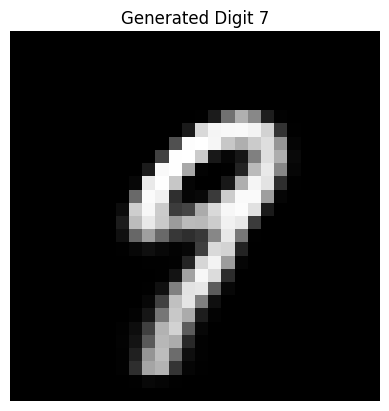

In [ ]:
model.eval()
with torch.no_grad():
    # Sample from latent space
    z = torch.randn(1, model.latent_dim).to(device)

    # Label = 7 → one-hot encode
    y = torch.zeros(1, 10).to(device)
    y[0, 9] = 1.0

    # Decode into an image
    sample = model.decode(z, y).cpu().view(28, 28)

    plt.imshow(sample, cmap="gray")
    plt.title("Generated Digit 7")
    plt.axis("off")
    plt.show()